
# IMPORTS

# DEVICE


# HYPERPARAMETERS




# LOAD MNIST


# AUTOENCODER MODEL




# CREATE MODEL




# TRAINING LOOP





# LOSS CURVE



# SAVE MODEL




# RECONSTRUCTION



# LATENT SPACE VISUALIZATION





# GENERATE IMAGES FROM LATENT SPACE




# Imports 

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

# Device 

In [3]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)


Using device: cpu


# Hyperparameters 

In [4]:

batch_size = 128

latent_dim = 2

epochs = 20

lr = 1e-3

# Convert to tensor data 

In [5]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

# Define the Auto Encoder 

In [6]:
class AutoEncoder(nn.Module):

    def __init__(self, latent_dim):

        super().__init__()

        # ====================================================
        # ENCODER
        # ====================================================

        self.encoder = nn.Sequential(

            nn.Linear(28 * 28, 512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, latent_dim)

        )

        # ====================================================
        # DECODER
        # ====================================================

        self.decoder = nn.Sequential(

            nn.Linear(latent_dim, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 28 * 28),

            nn.Sigmoid()

        )

    # ========================================================
    # FORWARD
    # ========================================================

    def forward(self, x):

        x = x.view(-1, 28 * 28)

        z = self.encoder(x)

        xhat = self.decoder(z)

        return xhat, z


# Initialize the model , optmizer and define the loss

In [7]:

model = AutoEncoder(latent_dim).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=lr
)

criterion = nn.MSELoss()

# Training Loop

In [8]:
losses = []

print("\nTraining AutoEncoder...\n")

for epoch in range(epochs):

    epoch_loss = 0.0

    for images, _ in loader:

        images = images.to(device)

        # ====================================================
        # FORWARD
        # ====================================================

        xhat, z = model(images)

        loss = criterion(
            xhat,
            images.view(-1, 28 * 28)
        )

        # ====================================================
        # BACKPROP
        # ====================================================

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)

    losses.append(avg_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {avg_loss:.6f}"
    )


Training AutoEncoder...

Epoch [1/20] Loss: 0.055512
Epoch [2/20] Loss: 0.044193
Epoch [3/20] Loss: 0.041783
Epoch [4/20] Loss: 0.040563
Epoch [5/20] Loss: 0.039715
Epoch [6/20] Loss: 0.039055
Epoch [7/20] Loss: 0.038562
Epoch [8/20] Loss: 0.038098
Epoch [9/20] Loss: 0.037696
Epoch [10/20] Loss: 0.037470
Epoch [11/20] Loss: 0.037195
Epoch [12/20] Loss: 0.036953
Epoch [13/20] Loss: 0.036716
Epoch [14/20] Loss: 0.036462
Epoch [15/20] Loss: 0.036248
Epoch [16/20] Loss: 0.036066
Epoch [17/20] Loss: 0.035895
Epoch [18/20] Loss: 0.035694
Epoch [19/20] Loss: 0.035622
Epoch [20/20] Loss: 0.035486


# LOss plot 

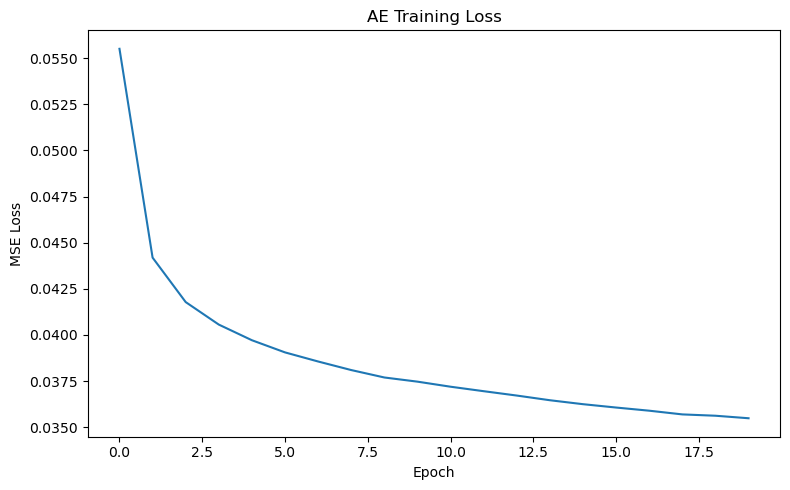


Training complete.


In [14]:
np.save("ae_loss.npy",losses)
plt.figure(figsize=(8,5))

plt.plot(losses)

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.title("AE Training Loss")

plt.tight_layout()

plt.savefig(
    "ae_loss_curve.png",
    dpi=300
)

plt.show()

print("\nTraining complete.")

# Save the model for future use 

In [10]:

torch.save(
    model.state_dict(),
    "mnist_autoencoder.pt"
)

print("\nModel saved.")


Model saved.


# Latent vizualization 

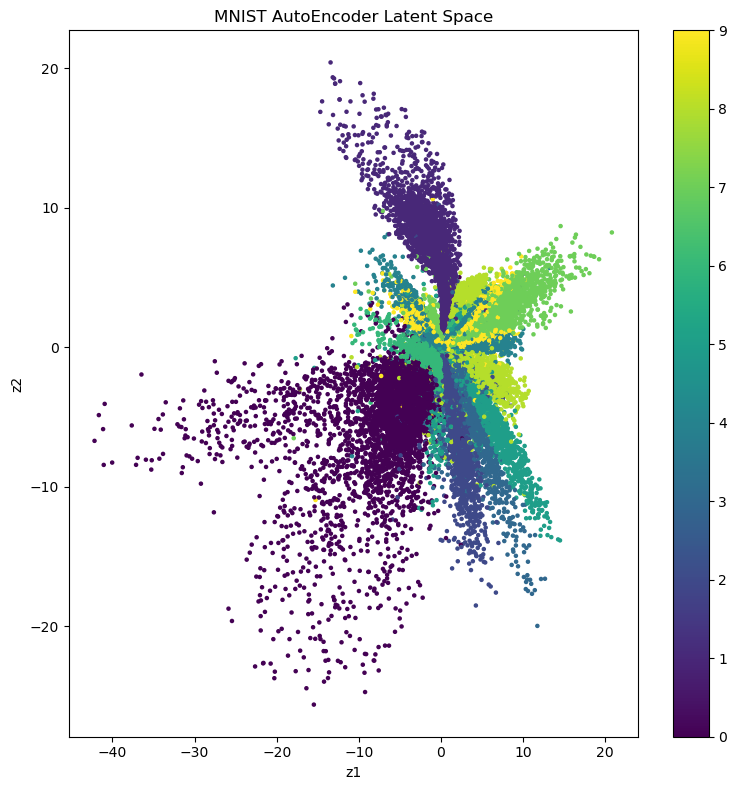

In [11]:
latent_vectors = []

all_labels = []

with torch.no_grad():

    for images, labels in loader:

        images = images.to(device)

        _, z = model(images)

        latent_vectors.append(
            z.cpu().numpy()
        )

        all_labels.append(
            labels.numpy()
        )

latent_vectors = np.concatenate(
    latent_vectors,
    axis=0
)

all_labels = np.concatenate(
    all_labels,
    axis=0
)

# ============================================================
# PLOT LATENT SPACE
# ============================================================

if latent_dim >= 2:

    plt.figure(figsize=(8,8))

    scatter = plt.scatter(

        latent_vectors[:,0],
        latent_vectors[:,1],

        c=all_labels,

        s=5
    )

    plt.colorbar(scatter)

    plt.xlabel("z1")
    plt.ylabel("z2")

    plt.title("MNIST AutoEncoder Latent Space")

    plt.tight_layout()

    plt.savefig(
        "ae_latent_space.png",
        dpi=300
    )

# reconstructions 

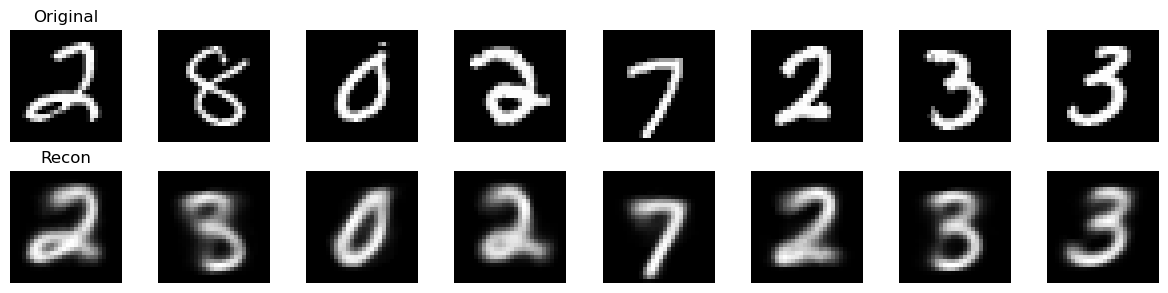

In [12]:
model.eval()

with torch.no_grad():

    images, labels = next(iter(loader))

    images = images.to(device)

    xhat, z = model(images)

original = images[:8].cpu().numpy()

reconstructed = xhat[:8].cpu().numpy()

# ============================================================
# PLOT RECONSTRUCTION
# ============================================================

fig, axes = plt.subplots(2, 8, figsize=(12,3))

for i in range(8):

    # ========================================================
    # ORIGINAL
    # ========================================================

    axes[0,i].imshow(
        original[i].reshape(28,28),
        cmap='gray'
    )

    axes[0,i].axis("off")

    # ========================================================
    # RECONSTRUCTED
    # ========================================================

    axes[1,i].imshow(
        reconstructed[i].reshape(28,28),
        cmap='gray'
    )

    axes[1,i].axis("off")

axes[0,0].set_title("Original")
axes[1,0].set_title("Recon")

plt.tight_layout()

plt.savefig(
    "ae_reconstruction.png",
    dpi=300
)


# GENERATION 

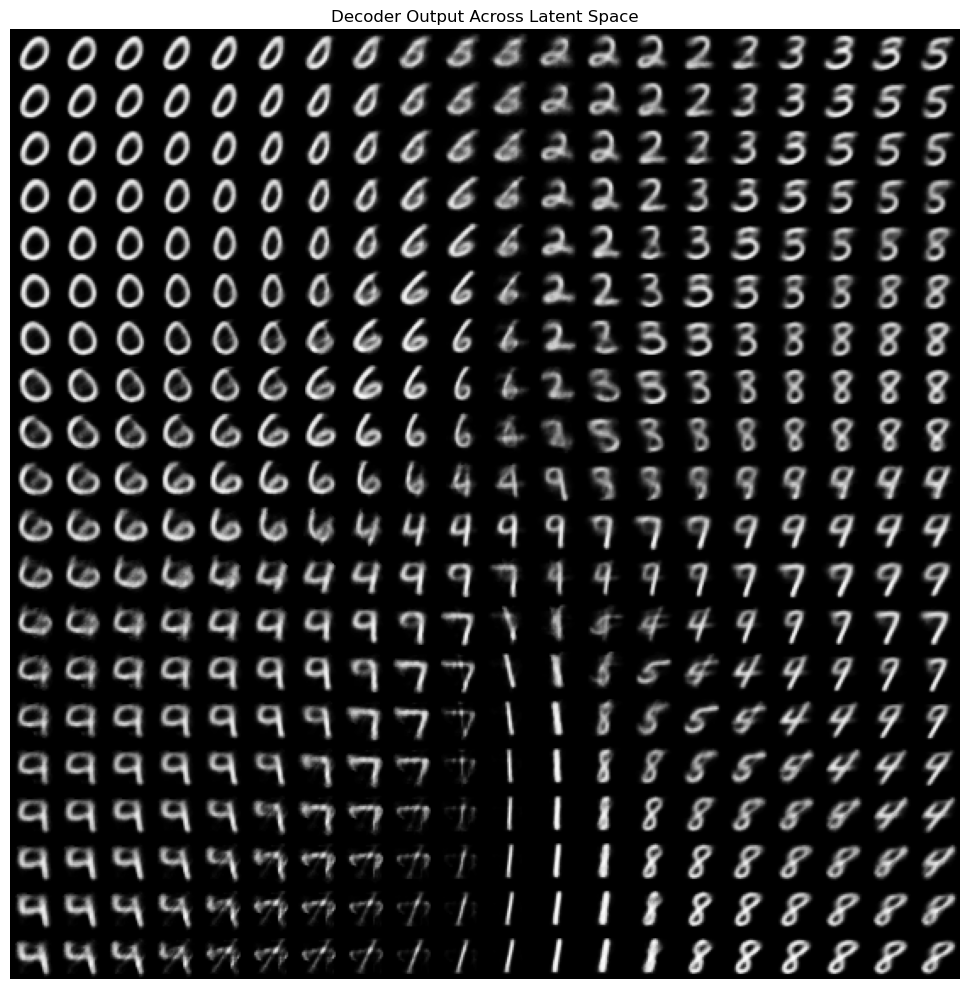

In [13]:
if latent_dim == 2:

    n = 20

    grid_x = np.linspace(-4, 4, n)

    grid_y = np.linspace(-4, 4, n)

    canvas = np.zeros((28*n, 28*n))

    with torch.no_grad():

        for i, yi in enumerate(grid_y):

            for j, xi in enumerate(grid_x):

                z = torch.tensor(
                    [[xi, yi]],
                    dtype=torch.float32
                ).to(device)

                img = model.decoder(z)

                img = img.cpu().numpy().reshape(28,28)

                canvas[
                    i*28:(i+1)*28,
                    j*28:(j+1)*28
                ] = img

    plt.figure(figsize=(10,10))

    plt.imshow(canvas, cmap='gray')

    plt.axis("off")

    plt.title("Decoder Output Across Latent Space")

    plt.tight_layout()

    plt.savefig(
        "ae_generated_grid.png",
        dpi=300
    )
